<a href="https://colab.research.google.com/github/hsb-ctrl-zy/multi-team1-project/blob/main/%EC%BD%94%EB%9E%A9/%ED%82%A4%EC%9B%8C%EB%93%9C_%EC%8A%A4%ED%84%B0%ED%95%91.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 필요 라이브러리 설치 및 로드

In [1]:
# !pip install pymysql

In [3]:
import pymysql

### SQL 연결

In [4]:
#MySQL 연결 정보 설정

#데이터베이스 연결
conn=pymysql.connect(
    host=host_name,
    user=user_name,
    password=password_val,
    database=db_name,
    port=port_num,
    charset='utf8'
)

### MySQL 연결 상태 확인

In [5]:
if conn:
    try:
        # 커서를 생성하여 쿼리 실행 준비
        with conn.cursor() as cursor:
            # 간단한 쿼리로 현재 연결된 데이터베이스 이름을 확인
            cursor.execute("SELECT DATABASE();")
            result = cursor.fetchone()
            if result and result[0]:
                print(f"데이터베이스 연결이 성공적으로 확인되었습니다. 현재 데이터베이스: {result[0]}")
            else:
                print("데이터베이스에 연결되었지만, 현재 데이터베이스 이름을 가져올 수 없습니다.")
    except pymysql.Error as e:
        print(f"데이터베이스 연결 확인 중 오류 발생: {e}")
        print("연결에 문제가 있을 수 있습니다.")
else:
    print("데이터베이스 연결 객체(conn)가 생성되지 않았습니다. 연결이 실패했을 수 있습니다.")

데이터베이스 연결이 성공적으로 확인되었습니다. 현재 데이터베이스: geo_db


### 형태소 분석을 위한 라이브러리 설치

In [6]:
# !pip install konlpy

### 데이터 로드 및 형태소 분석 준비

In [7]:
import pandas as pd

try:
    with conn.cursor() as cursor:
        # raw_data_table에서 product_name, text_contents, brand_type, page_id 컬럼을 가져옵니다.
        sql = "SELECT product_name, text_contents, brand_type, page_id FROM raw_data_table"
        cursor.execute(sql)
        data = cursor.fetchall()

    # 데이터를 Pandas DataFrame으로 변환합니다.
    df = pd.DataFrame(data, columns=['product_name', 'text_contents', 'brand_type', 'page_id'])
    print("데이터를 성공적으로 로드했습니다. 처음 5개 행을 표시합니다:")
    display(df.head())

    print("\nbrand_type 컬럼의 고유 값과 그 개수:")
    display(df['brand_type'].value_counts())

except pymysql.Error as e:
    print(f"데이터 로드 중 오류 발생: {e}")
    df = pd.DataFrame(columns=['product_name', 'text_contents', 'brand_type', 'page_id'])

데이터를 성공적으로 로드했습니다. 처음 5개 행을 표시합니다:


,product_name,text_contents,brand_type,page_id
0,남성 쿨 원턱 와이드 트레이닝팬츠 PHG2PT1759,,대기업,1
1,트레이닝 반바지 249PT262,[엔비에이][NBA] 스몰로고 트레이닝 반바지(N262TP942P)\n시그니처 로고...,대기업,2
2,남성 여성 커플 냉장고바지 쿨팬츠 8부 9부 아이스바지,,대기업,3
3,캘빈클라인 에센셜 셋업 3종 세트 남여공용,,대기업,4
4,7부 바지 스판 밴딩 냉장고 쿨링 아이스 냉감 칠부 츄리닝 트레이닝 팬츠,,대기업,5



brand_type 컬럼의 고유 값과 그 개수:


,count
brand_type,
대기업,5750
소상공인,3013


In [24]:
analyzers = ['Okt', 'Kkma', 'Komoran', 'Kiwi']

# 품사 유형 매핑 (한글 이름으로 변경)
pos_type_mapping = {
    'noun_ratio': '명사 비율',
    'adjective_ratio': '형용사 비율',
    'numeral_ratio': '수사 비율',
    'verb_ratio': '동사 비율',
    'josa_ratio': '조사 비율',
    'eomi_ratio': '어미 비율',
    'special_char_ratio': '특수문자 비율'
}

# 품사 유형의 순서 정의
ordered_pos_types = [
    '명사 비율', '형용사 비율', '수사 비율',
    '동사 비율', '조사 비율', '어미 비율',
    '특수문자 비율'
]

print("형태소 분석기 목록 및 품사 유형 매핑 정의 완료.")

형태소 분석기 목록 및 품사 유형 매핑 정의 완료.


### 'brand_type' 컬럼을 기준으로 데이터 분리

In [8]:
# '대기업'과 '소상공인'으로 데이터 분리
df_large_enterprise = df[df['brand_type'] == '대기업'].copy()
df_small_business = df[df['brand_type'] == '소상공인'].copy()

print("'대기업' 데이터프레임 (df_large_enterprise) 처음 5개 행:")
display(df_large_enterprise.head())

print("\n'소상공인' 데이터프레임 (df_small_business) 처음 5개 행:")
display(df_small_business.head())

print(f"\n'대기업' 데이터 개수: {len(df_large_enterprise)}개")
print(f"'소상공인' 데이터 개수: {len(df_small_business)}개")

'대기업' 데이터프레임 (df_large_enterprise) 처음 5개 행:


,product_name,text_contents,brand_type,page_id
0,남성 쿨 원턱 와이드 트레이닝팬츠 PHG2PT1759,,대기업,1
1,트레이닝 반바지 249PT262,[엔비에이][NBA] 스몰로고 트레이닝 반바지(N262TP942P)\n시그니처 로고...,대기업,2
2,남성 여성 커플 냉장고바지 쿨팬츠 8부 9부 아이스바지,,대기업,3
3,캘빈클라인 에센셜 셋업 3종 세트 남여공용,,대기업,4
4,7부 바지 스판 밴딩 냉장고 쿨링 아이스 냉감 칠부 츄리닝 트레이닝 팬츠,,대기업,5



'소상공인' 데이터프레임 (df_small_business) 처음 5개 행:


,product_name,text_contents,brand_type,page_id
2794,[허리잘록!/여름데이트?] 플래닝 핀턱 스트링 나시 블라우스,플래닝 핀턱 스트링 나시 블라우스\n-체형에 맞춰 조절 가능한 끈 길이\n- 허리 ...,소상공인,2816
2795,[팔뚝삭제/허얇핏] 앤드리 도트 콩단추 반팔 블라우스,앤드리 도트 콩단추 반팔 블라우스\n- 러블리한 도트 패턴으로 포인트를 더한 블라우...,소상공인,2817
2796,*7col [햇빛막아주는/여리!] 파파야 시스루 썸머 루즈핏 셔츠,파파야 시스루 썸머 루즈핏 셔츠\n- 체형에 구애 없는 루즈핏 실루엣\n- 힙을 덮...,소상공인,2818
2797,[여리여리-/부유방부각X] 슈디 캉캉 나시 블라우스,슈디 캉캉 나시 블라우스\n- 은은하게 비치는 쉬폰 소재로 여리여리한 무드\n-캉캉...,소상공인,2819
2798,[여름내내/힙덮는] 먼데이 린넨 스트라이프 루즈핏 셔츠,먼데이 린넨 스트라이프 루즈핏 셔츠\n- 여름시즌 활용하기 좋은 린넨 원단\n- 루...,소상공인,2820



'대기업' 데이터 개수: 5750개
'소상공인' 데이터 개수: 3013개


------------------------------------------------
------------------------------------------------

### 1.'대기업' 및 '소상공인' 데이터 형태소 분석

#### 형태소 분석기 정의

Okt 정의

In [9]:
from konlpy.tag import Okt
import re

okt = Okt()

# --- 특수문자 비율 function (common for all) ---
def get_special_char_ratio(text):
    if not isinstance(text, str) or not text.strip():
        return {'special_char_ratio': 0, 'total_char_count': 0}

    total_char_count = len(text)
    if total_char_count == 0:
        return {'special_char_ratio': 0, 'total_char_count': 0}

    # 한글, 영어, 숫자를 제외한 모든 문자를 특수문자로 간주
    special_char_count = len(re.findall(r'[^\s\w가-힣]', text))

    return {
        'special_char_ratio': special_char_count / total_char_count,
        'total_char_count': total_char_count
    }

# --- Okt Functions ---
def get_pos_ratios(text):
    if not isinstance(text, str) or not text.strip():
        return {'noun_ratio': 0, 'adjective_ratio': 0, 'numeral_ratio': 0, 'verb_ratio': 0, 'josa_ratio': 0, 'eomi_ratio': 0, 'total_pos_count': 0}

    pos_tags = okt.pos(text)
    total_pos_count = len(pos_tags)

    if total_pos_count == 0:
        return {'noun_ratio': 0, 'adjective_ratio': 0, 'numeral_ratio': 0, 'verb_ratio': 0, 'josa_ratio': 0, 'eomi_ratio': 0, 'total_pos_count': 0}

    noun_count = sum(1 for word, tag in pos_tags if tag == 'Noun')
    adjective_count = sum(1 for word, tag in pos_tags if tag == 'Adjective')
    numeral_count = sum(1 for word, tag in pos_tags if tag == 'Number')
    verb_count = sum(1 for word, tag in pos_tags if tag == 'Verb')
    josa_count = sum(1 for word, tag in pos_tags if tag == 'Josa')
    eomi_count = sum(1 for word, tag in pos_tags if tag == 'Eomi')

    return {
        'noun_ratio': noun_count / total_pos_count,
        'adjective_ratio': adjective_count / total_pos_count,
        'numeral_ratio': numeral_count / total_pos_count,
        'verb_ratio': verb_count / total_pos_count,
        'josa_ratio': josa_count / total_pos_count,
        'eomi_ratio': eomi_count / total_pos_count,
        'total_pos_count': total_pos_count
    }

print("Okt 형태소 분석기 및 비율 계산 함수 정의 완료.")

Okt 형태소 분석기 및 비율 계산 함수 정의 완료.


KKma 정의

In [10]:
from konlpy.tag import Kkma
import re

kkma = Kkma()

# --- 특수문자 비율 function (common for all) ---
def get_special_char_ratio(text):
    if not isinstance(text, str) or not text.strip():
        return {'special_char_ratio': 0, 'total_char_count': 0}

    total_char_count = len(text)
    if total_char_count == 0:
        return {'special_char_ratio': 0, 'total_char_count': 0}

    # 한글, 영어, 숫자를 제외한 모든 문자를 특수문자로 간주
    special_char_count = len(re.findall(r'[^\s\w가-힣]', text))

    return {
        'special_char_ratio': special_char_count / total_char_count,
        'total_char_count': total_char_count
    }

# --- Kkma Functions ---
def get_pos_ratios_kkma(text):
    if not isinstance(text, str) or not text.strip():
        return {'noun_ratio': 0, 'adjective_ratio': 0, 'numeral_ratio': 0, 'verb_ratio': 0, 'josa_ratio': 0, 'eomi_ratio': 0, 'total_pos_count': 0}

    pos_tags = kkma.pos(text)
    total_pos_count = len(pos_tags)

    if total_pos_count == 0:
        return {'noun_ratio': 0, 'adjective_ratio': 0, 'numeral_ratio': 0, 'verb_ratio': 0, 'josa_ratio': 0, 'eomi_ratio': 0, 'total_pos_count': 0}

    noun_count = sum(1 for word, tag in pos_tags if tag.startswith('N'))
    adjective_count = sum(1 for word, tag in pos_tags if tag == 'VA')
    numeral_count = sum(1 for word, tag in pos_tags if tag == 'NR')
    verb_count = sum(1 for word, tag in pos_tags if tag == 'VV')
    josa_count = sum(1 for word, tag in pos_tags if tag.startswith('J'))
    eomi_count = sum(1 for word, tag in pos_tags if tag.startswith('E'))

    return {
        'noun_ratio': noun_count / total_pos_count,
        'adjective_ratio': adjective_count / total_pos_count,
        'numeral_ratio': numeral_count / total_pos_count,
        'verb_ratio': verb_count / total_pos_count,
        'josa_ratio': josa_count / total_pos_count,
        'eomi_ratio': eomi_count / total_pos_count,
        'total_pos_count': total_pos_count
    }

def get_special_char_ratio_kkma(text):
    return get_special_char_ratio(text)

print("Kkma 형태소 분석기 및 비율 계산 함수 정의 완료.")

Kkma 형태소 분석기 및 비율 계산 함수 정의 완료.


Komoran 정의

In [11]:
from konlpy.tag import Komoran
import re

komoran=Komoran()

# --- 특수문자 function (common for all) ---
def get_special_char_ratio(text):
    if not isinstance(text, str) or not text.strip():
        return {'special_char_ratio': 0, 'total_char_count': 0}

    total_char_count = len(text)
    if total_char_count == 0:
        return {'special_char_ratio': 0, 'total_char_count': 0}

    # 한글, 영어, 숫자를 제외한 모든 문자를 특수문자로 간주
    special_char_count = len(re.findall(r'[^\s\w가-힣]', text))

    return {
        'special_char_ratio': special_char_count / total_char_count,
        'total_char_count': total_char_count
    }

# --- Komoran Functions ---
def get_pos_ratios_komoran(text):
    if not isinstance(text, str) or not text.strip():
        return {'noun_ratio': 0, 'adjective_ratio': 0, 'numeral_ratio': 0, 'verb_ratio': 0, 'josa_ratio': 0, 'eomi_ratio': 0, 'total_pos_count': 0}

    pos_tags = komoran.pos(text)
    total_pos_count = len(pos_tags)

    if total_pos_count == 0:
        return {'noun_ratio': 0, 'adjective_ratio': 0, 'numeral_ratio': 0, 'verb_ratio': 0, 'josa_ratio': 0, 'eomi_ratio': 0, 'total_pos_count': 0}

    noun_count = sum(1 for word, tag in pos_tags if tag.startswith('N'))
    adjective_count = sum(1 for word, tag in pos_tags if tag == 'VA')
    numeral_count = sum(1 for word, tag in pos_tags if tag == 'NR')
    verb_count = sum(1 for word, tag in pos_tags if tag == 'VV')
    josa_count = sum(1 for word, tag in pos_tags if tag.startswith('J'))
    eomi_count = sum(1 for word, tag in pos_tags if tag.startswith('E'))

    return {
        'noun_ratio': noun_count / total_pos_count,
        'adjective_ratio': adjective_count / total_pos_count,
        'numeral_ratio': numeral_count / total_pos_count,
        'verb_ratio': verb_count / total_pos_count,
        'josa_ratio': josa_count / total_pos_count,
        'eomi_ratio': eomi_count / total_pos_count,
        'total_pos_count': total_pos_count
    }

def get_special_char_ratio_komoran(text):
    return get_special_char_ratio(text)

print("Komoran 형태소 분석기 및 비율 계산 함수 정의 완료.")

Komoran 형태소 분석기 및 비율 계산 함수 정의 완료.


Kiwi 정의

In [12]:
# !pip install kiwipiepy

In [13]:
from kiwipiepy import Kiwi
import re

kiwi = Kiwi()

# --- 특수문자 function (common for all) ---
def get_special_char_ratio(text):
    if not isinstance(text, str) or not text.strip():
        return {'special_char_ratio': 0, 'total_char_count': 0}

    total_char_count = len(text)
    if total_char_count == 0:
        return {'special_char_ratio': 0, 'total_char_count': 0}

    # 한글, 영어, 숫자를 제외한 모든 문자를 특수문자로 간주
    special_char_count = len(re.findall(r'[^\s\w가-힣]', text))

    return {
        'special_char_ratio': special_char_count / total_char_count,
        'total_char_count': total_char_count
    }

# --- Kiwi Functions ---
def get_pos_ratios_kiwi(text):
    if not isinstance(text, str) or not text.strip():
        return {'noun_ratio': 0, 'adjective_ratio': 0, 'numeral_ratio': 0, 'verb_ratio': 0, 'josa_ratio': 0, 'eomi_ratio': 0, 'total_pos_count': 0}

    result = kiwi.analyze(text)
    if not result or not result[0]:
        return {'noun_ratio': 0, 'adjective_ratio': 0, 'numeral_ratio': 0, 'verb_ratio': 0, 'josa_ratio': 0, 'eomi_ratio': 0, 'total_pos_count': 0}

    pos_tags = result[0][0]
    total_pos_count = len(pos_tags)

    if total_pos_count == 0:
        return {'noun_ratio': 0, 'adjective_ratio': 0, 'numeral_ratio': 0, 'verb_ratio': 0, 'josa_ratio': 0, 'eomi_ratio': 0, 'total_pos_count': 0}

    noun_count = sum(1 for word, tag, _, _ in pos_tags if tag.startswith('N'))
    adjective_count = sum(1 for word, tag, _, _ in pos_tags if tag.startswith('VA'))
    numeral_count = sum(1 for word, tag, _, _ in pos_tags if tag.startswith('NR'))
    verb_count = sum(1 for word, tag, _, _ in pos_tags if tag.startswith('V'))
    josa_count = sum(1 for word, tag, _, _ in pos_tags if tag.startswith('J'))
    eomi_count = sum(1 for word, tag, _, _ in pos_tags if tag.startswith('E'))

    return {
        'noun_ratio': noun_count / total_pos_count,
        'adjective_ratio': adjective_count / total_pos_count,
        'numeral_ratio': numeral_count / total_pos_count,
        'verb_ratio': verb_count / total_pos_count,
        'josa_ratio': josa_count / total_pos_count,
        'eomi_ratio': eomi_count / total_pos_count,
        'total_pos_count': total_pos_count
    }

def get_special_char_ratio_kiwi(text):
    return get_special_char_ratio(text)

print("Kiwi 형태소 분석기 및 비율 계산 함수 정의 완료.")

Kiwi 형태소 분석기 및 비율 계산 함수 정의 완료.


----------------------------------------
----------------------------------------

### 'keyword_stuffing_score' 기반 형태소 분석

In [14]:
import pandas as pd
import pymysql

try:
    # 기존 연결이 있다면 닫고 새로 연결
    if 'conn' in globals() and conn.open: # 'conn' 변수가 존재하고 연결이 열려있는지 확인
        conn.close()
        print("기존 데이터베이스 연결을 닫고 새로 연결합니다.")

    # 새로운 연결 설정
    conn = pymysql.connect(
        host=host_name,
        user=user_name,
        password=password_val,
        database=db_name,
        port=port_num,
        charset='utf8'
    )
    print("데이터베이스에 다시 연결했습니다.")

    with conn.cursor() as cursor:
        # diagnosis_table의 모든 컬럼을 가져와 스키마를 확인합니다.
        sql = "SELECT * FROM diagnosis_table"
        cursor.execute(sql)
        data_diagnosis = cursor.fetchall()

        # 컬럼 이름 가져오기
        columns = [desc[0] for desc in cursor.description]

    # 데이터를 Pandas DataFrame으로 변환합니다.
    df_diagnosis = pd.DataFrame(data_diagnosis, columns=columns)

    # 데이터가 로드되었는지 확인
    if df_diagnosis.empty:
        print("경고: diagnosis_table에서 로드된 데이터가 없습니다. 모든 'keyword_stuffing_score' 그룹 데이터프레임이 비어있을 수 있습니다.")
    else:
        print("diagnosis_table 데이터를 성공적으로 로드했습니다. 처음 5개 행을 표시합니다:")
        display(df_diagnosis.head())

        print("\ndiagnosis_table의 컬럼 목록:")
        print(df_diagnosis.columns.tolist())

        if 'keyword_stuffing_score' in df_diagnosis.columns:
            print("\nkeyword_stuffing_score 컬럼의 통계 요약:")
            display(df_diagnosis['keyword_stuffing_score'].describe())
        else:
            print("경고: 'keyword_stuffing_score' 컬럼이 diagnosis_table에 없습니다. 다른 컬럼을 사용하여 데이터를 분리해야 합니다.")

except pymysql.Error as e:
    print(f"데이터 로드 중 오류 발생: {e}")
    # 오류 발생 시 빈 DataFrame 생성하여 다음 셀에서 오류가 나지 않도록 함
    df_diagnosis = pd.DataFrame(columns=['product_name', 'text_contents', 'keyword_stuffing_score'])
    print("데이터 로드 오류로 인해 빈 DataFrame이 생성되었습니다. 컬럼 정보를 확인하려면 쿼리를 수정해야 합니다.")

기존 데이터베이스 연결을 닫고 새로 연결합니다.
데이터베이스에 다시 연결했습니다.
diagnosis_table 데이터를 성공적으로 로드했습니다. 처음 5개 행을 표시합니다:


,dx_id,page_id,is_corrected,model_ver,text_ratio_score,hybrid_search_score,keyword_stuffing_score,json_ld_score,image_alt_score,raw_details,geo_score
0,1,1,0,3.2.0,0.00,0.0,0.859,0.3250,0.285,"{""details"": {""json_ld"": {""is_valid"": true, ""tr...",29
1,2,2,0,3.2.0,0.72,0.0,0.924,0.3250,0.190,"{""details"": {""json_ld"": {""is_valid"": true, ""tr...",43
2,3,3,0,3.2.0,0.00,0.0,0.483,0.3250,0.029,"{""details"": {""json_ld"": {""is_valid"": true, ""tr...",17
3,4,4,0,3.2.0,0.00,0.0,0.734,0.3250,0.440,"{""details"": {""json_ld"": {""is_valid"": true, ""tr...",30
4,5,5,0,3.2.0,0.00,0.0,0.681,0.4125,0.000,"{""details"": {""json_ld"": {""is_valid"": true, ""tr...",22



diagnosis_table의 컬럼 목록:
['dx_id', 'page_id', 'is_corrected', 'model_ver', 'text_ratio_score', 'hybrid_search_score', 'keyword_stuffing_score', 'json_ld_score', 'image_alt_score', 'raw_details', 'geo_score']

keyword_stuffing_score 컬럼의 통계 요약:


,keyword_stuffing_score
count,8763.000000
mean,0.733420
std,0.175127
min,0.140000
25%,0.591000
50%,0.723000
75%,0.895000
max,1.000000


#### 'keyword_stuffing_score' 컬럼을 기준으로 데이터 분리

In [15]:
# raw_data_table(df)와 diagnosis_table(df_diagnosis)를 page_id를 기준으로 병합
# product_name, text_contents 컬럼은 df에서, keyword_stuffing_score 컬럼은 df_diagnosis에서 가져옵니다.
# inner join을 사용하여 두 테이블에 모두 존재하는 page_id만 남깁니다.
df_merged_analysis = pd.merge(
    df[['page_id', 'product_name', 'text_contents']],
    df_diagnosis[['page_id', 'keyword_stuffing_score']],
    on='page_id',
    how='inner'
)

print("raw_data_table과 diagnosis_table 병합 완료. 처음 5개 행을 표시합니다:")
display(df_merged_analysis.head())
print(f"병합된 데이터프레임 크기: {len(df_merged_analysis)}개")

# 병합된 데이터프레임을 0.66을 기준으로 데이터 분리
df_low_stuffing = df_merged_analysis[df_merged_analysis['keyword_stuffing_score'] < 0.66].copy()
df_high_stuffing = df_merged_analysis[df_merged_analysis['keyword_stuffing_score'] >= 0.66].copy()

print("'keyword_stuffing_score' < 0.66 데이터프레임 (df_low_stuffing) 처음 5개 행:")
display(df_low_stuffing.head())

print("\n'keyword_stuffing_score' >= 0.66 데이터프레임 (df_high_stuffing) 처음 5개 행:")
display(df_high_stuffing.head())

print(f"\n'keyword_stuffing_score' < 0.66 데이터 개수: {len(df_low_stuffing)}개")
print(f"'keyword_stuffing_score' >= 0.66 데이터 개수: {len(df_high_stuffing)}개")

raw_data_table과 diagnosis_table 병합 완료. 처음 5개 행을 표시합니다:


,page_id,product_name,text_contents,keyword_stuffing_score
0,1,남성 쿨 원턱 와이드 트레이닝팬츠 PHG2PT1759,,0.859
1,2,트레이닝 반바지 249PT262,[엔비에이][NBA] 스몰로고 트레이닝 반바지(N262TP942P)\n시그니처 로고...,0.924
2,3,남성 여성 커플 냉장고바지 쿨팬츠 8부 9부 아이스바지,,0.483
3,4,캘빈클라인 에센셜 셋업 3종 세트 남여공용,,0.734
4,5,7부 바지 스판 밴딩 냉장고 쿨링 아이스 냉감 칠부 츄리닝 트레이닝 팬츠,,0.681


병합된 데이터프레임 크기: 8763개
'keyword_stuffing_score' < 0.66 데이터프레임 (df_low_stuffing) 처음 5개 행:


,page_id,product_name,text_contents,keyword_stuffing_score
2,3,남성 여성 커플 냉장고바지 쿨팬츠 8부 9부 아이스바지,,0.483
7,8,[롯데백화점] (행사)](남여공용) 프레시벤트 폴튼 트레이닝 쇼츠 DXTB7A053,다크카키(DKS)\n민트(MTS)\n스카이블루(SBL)\n다크그레이(GRD)\n블랙...,0.481
8,9,[하프클럽] 25SS 신상 쉴드테크 남녀공용 이지팬츠 3종(7부),？？？？？？？,0.506
10,11,남자 여름 반팔반바지세트 트레이닝 아노락 셋업 세트 5부 반바지,반품교환시 공급사에서 직접 수거접수하는 업체입니다. 단순변심으로 인한 반품시 왕복배...,0.516
11,12,[하프클럽/슈퍼맨아웃도어]여름_MAB냉감스판트레이닝 남자 남성 쿨 냉감 스판 추리닝...,,0.440



'keyword_stuffing_score' >= 0.66 데이터프레임 (df_high_stuffing) 처음 5개 행:


,page_id,product_name,text_contents,keyword_stuffing_score
0,1,남성 쿨 원턱 와이드 트레이닝팬츠 PHG2PT1759,,0.859
1,2,트레이닝 반바지 249PT262,[엔비에이][NBA] 스몰로고 트레이닝 반바지(N262TP942P)\n시그니처 로고...,0.924
3,4,캘빈클라인 에센셜 셋업 3종 세트 남여공용,,0.734
4,5,7부 바지 스판 밴딩 냉장고 쿨링 아이스 냉감 칠부 츄리닝 트레이닝 팬츠,,0.681
5,6,[마르치오] 남성 냉감 라운지웨어 상하의 4종 세트,,0.685



'keyword_stuffing_score' < 0.66 데이터 개수: 3056개
'keyword_stuffing_score' >= 0.66 데이터 개수: 5707개


#### Okt 형태소 분석 - 'keyword_stuffing_score' 그룹에 적용

In [16]:
# df_low_stuffing 및 df_high_stuffing에 Okt 형태소 분석 적용
def apply_okt_analysis_to_df(df_target):
    # product_name 컬럼에 형태소 분석 함수 적용
    product_name_pos_results = df_target['product_name'].apply(get_pos_ratios)
    df_target['product_name_noun_ratio'] = product_name_pos_results.apply(lambda x: x['noun_ratio'])
    df_target['product_name_adjective_ratio'] = product_name_pos_results.apply(lambda x: x['adjective_ratio'])
    df_target['product_name_numeral_ratio'] = product_name_pos_results.apply(lambda x: x['numeral_ratio'])
    df_target['product_name_verb_ratio'] = product_name_pos_results.apply(lambda x: x['verb_ratio'])
    df_target['product_name_josa_ratio'] = product_name_pos_results.apply(lambda x: x['josa_ratio'])
    df_target['product_name_eomi_ratio'] = product_name_pos_results.apply(lambda x: x['eomi_ratio'])

    # product_name 컬럼에 특수문자 비율 함수 적용
    product_name_special_char_results = df_target['product_name'].apply(get_special_char_ratio)
    df_target['product_name_special_char_ratio'] = product_name_special_char_results.apply(lambda x: x['special_char_ratio'])

    # text_contents 컬럼에 형태소 분석 함수 적용
    text_contents_pos_results = df_target['text_contents'].apply(get_pos_ratios)
    df_target['text_contents_noun_ratio'] = text_contents_pos_results.apply(lambda x: x['noun_ratio'])
    df_target['text_contents_adjective_ratio'] = text_contents_pos_results.apply(lambda x: x['adjective_ratio'])
    df_target['text_contents_numeral_ratio'] = text_contents_pos_results.apply(lambda x: x['numeral_ratio'])
    df_target['text_contents_verb_ratio'] = text_contents_pos_results.apply(lambda x: x['verb_ratio'])
    df_target['text_contents_josa_ratio'] = text_contents_pos_results.apply(lambda x: x['josa_ratio'])
    df_target['text_contents_eomi_ratio'] = text_contents_pos_results.apply(lambda x: x['eomi_ratio'])

    # text_contents 컬럼에 특수문자 비율 함수 적용
    text_contents_special_char_results = df_target['text_contents'].apply(get_special_char_ratio)
    df_target['text_contents_special_char_ratio'] = text_contents_special_char_results.apply(lambda x: x['special_char_ratio'])
    return df_target

df_low_stuffing = apply_okt_analysis_to_df(df_low_stuffing.copy())
df_high_stuffing = apply_okt_analysis_to_df(df_high_stuffing.copy())

print("Okt 분석을 이용한 'keyword_stuffing_score' 그룹 데이터의 형태소 분석 및 특수문자 비율 계산 완료.")
print(f"df_low_stuffing 컬럼 개수: {len(df_low_stuffing.columns)}")
print(f"df_high_stuffing 컬럼 개수: {len(df_high_stuffing.columns)}")

Okt 분석을 이용한 'keyword_stuffing_score' 그룹 데이터의 형태소 분석 및 특수문자 비율 계산 완료.
df_low_stuffing 컬럼 개수: 18
df_high_stuffing 컬럼 개수: 18


#### Kkma 형태소 분석 - 'keyword_stuffing_score' 그룹에 적용

In [17]:
# df_low_stuffing 및 df_high_stuffing에 Kkma 형태소 분석 적용
def apply_kkma_analysis_to_df(df_target):
    # product_name 컬럼에 Kkma 형태소 분석 함수 적용
    product_name_pos_results_kkma = df_target['product_name'].apply(get_pos_ratios_kkma)
    df_target['product_name_kkma_noun_ratio'] = product_name_pos_results_kkma.apply(lambda x: x['noun_ratio'])
    df_target['product_name_kkma_adjective_ratio'] = product_name_pos_results_kkma.apply(lambda x: x['adjective_ratio'])
    df_target['product_name_kkma_numeral_ratio'] = product_name_pos_results_kkma.apply(lambda x: x['numeral_ratio'])
    df_target['product_name_kkma_verb_ratio'] = product_name_pos_results_kkma.apply(lambda x: x['verb_ratio'])
    df_target['product_name_kkma_josa_ratio'] = product_name_pos_results_kkma.apply(lambda x: x['josa_ratio'])
    df_target['product_name_kkma_eomi_ratio'] = product_name_pos_results_kkma.apply(lambda x: x['eomi_ratio'])

    # product_name 컬럼에 특수문자 비율 함수 적용 (Kkma 버전)
    product_name_special_char_results_kkma = df_target['product_name'].apply(get_special_char_ratio_kkma)
    df_target['product_name_kkma_special_char_ratio'] = product_name_special_char_results_kkma.apply(lambda x: x['special_char_ratio'])

    # text_contents 컬럼에 Kkma 형태소 분석 함수 적용
    text_contents_pos_results_kkma = df_target['text_contents'].apply(get_pos_ratios_kkma)
    df_target['text_contents_kkma_noun_ratio'] = text_contents_pos_results_kkma.apply(lambda x: x['noun_ratio'])
    df_target['text_contents_kkma_adjective_ratio'] = text_contents_pos_results_kkma.apply(lambda x: x['adjective_ratio'])
    df_target['text_contents_kkma_numeral_ratio'] = text_contents_pos_results_kkma.apply(lambda x: x['numeral_ratio'])
    df_target['text_contents_kkma_verb_ratio'] = text_contents_pos_results_kkma.apply(lambda x: x['verb_ratio'])
    df_target['text_contents_kkma_josa_ratio'] = text_contents_pos_results_kkma.apply(lambda x: x['josa_ratio'])
    df_target['text_contents_kkma_eomi_ratio'] = text_contents_pos_results_kkma.apply(lambda x: x['eomi_ratio'])

    # text_contents 컬럼에 특수문자 비율 함수 적용 (Kkma 버전)
    text_contents_special_char_results_kkma = df_target['text_contents'].apply(get_special_char_ratio_kkma)
    df_target['text_contents_kkma_special_char_ratio'] = text_contents_special_char_results_kkma.apply(lambda x: x['special_char_ratio'])
    return df_target

df_low_stuffing = apply_kkma_analysis_to_df(df_low_stuffing.copy())
df_high_stuffing = apply_kkma_analysis_to_df(df_high_stuffing.copy())

print("Kkma 분석을 이용한 'keyword_stuffing_score' 그룹 데이터의 형태소 분석 및 특수문자 비율 계산 완료.")
display(df_low_stuffing.head())
display(df_high_stuffing.head())

Kkma 분석을 이용한 'keyword_stuffing_score' 그룹 데이터의 형태소 분석 및 특수문자 비율 계산 완료.


,page_id,product_name,text_contents,keyword_stuffing_score,product_name_noun_ratio,product_name_adjective_ratio,product_name_numeral_ratio,product_name_verb_ratio,product_name_josa_ratio,product_name_eomi_ratio,...,product_name_kkma_josa_ratio,product_name_kkma_eomi_ratio,product_name_kkma_special_char_ratio,text_contents_kkma_noun_ratio,text_contents_kkma_adjective_ratio,text_contents_kkma_numeral_ratio,text_contents_kkma_verb_ratio,text_contents_kkma_josa_ratio,text_contents_kkma_eomi_ratio,text_contents_kkma_special_char_ratio
2,3,남성 여성 커플 냉장고바지 쿨팬츠 8부 9부 아이스바지,,0.483,0.750000,0.0,0.166667,0.000000,0.083333,0.0,...,0.000000,0.071429,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,8,[롯데백화점] (행사)](남여공용) 프레시벤트 폴튼 트레이닝 쇼츠 DXTB7A053,다크카키(DKS)\n민트(MTS)\n스카이블루(SBL)\n다크그레이(GRD)\n블랙...,0.481,0.476190,0.0,0.095238,0.047619,0.000000,0.0,...,0.000000,0.038462,0.152174,0.241379,0.034483,0.000000,0.000000,0.000000,0.034483,0.214286
8,9,[하프클럽] 25SS 신상 쉴드테크 남녀공용 이지팬츠 3종(7부),？？？？？？？,0.506,0.500000,0.0,0.150000,0.000000,0.000000,0.0,...,0.000000,0.090909,0.111111,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
10,11,남자 여름 반팔반바지세트 트레이닝 아노락 셋업 세트 5부 반바지,반품교환시 공급사에서 직접 수거접수하는 업체입니다. 단순변심으로 인한 반품시 왕복배...,0.516,0.769231,0.0,0.076923,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.590296,0.010782,0.016173,0.056604,0.105121,0.091644,0.039801
11,12,[하프클럽/슈퍼맨아웃도어]여름_MAB냉감스판트레이닝 남자 남성 쿨 냉감 스판 추리닝...,,0.440,0.800000,0.0,0.000000,0.000000,0.000000,0.0,...,0.066667,0.066667,0.046875,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


,page_id,product_name,text_contents,keyword_stuffing_score,product_name_noun_ratio,product_name_adjective_ratio,product_name_numeral_ratio,product_name_verb_ratio,product_name_josa_ratio,product_name_eomi_ratio,...,product_name_kkma_josa_ratio,product_name_kkma_eomi_ratio,product_name_kkma_special_char_ratio,text_contents_kkma_noun_ratio,text_contents_kkma_adjective_ratio,text_contents_kkma_numeral_ratio,text_contents_kkma_verb_ratio,text_contents_kkma_josa_ratio,text_contents_kkma_eomi_ratio,text_contents_kkma_special_char_ratio
0,1,남성 쿨 원턱 와이드 트레이닝팬츠 PHG2PT1759,,0.859,0.545455,0.000000,0.181818,0.0,0.000000,0.0,...,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000
1,2,트레이닝 반바지 249PT262,[엔비에이][NBA] 스몰로고 트레이닝 반바지(N262TP942P)\n시그니처 로고...,0.924,0.400000,0.000000,0.400000,0.0,0.000000,0.0,...,0.000000,0.000000,0.000000,0.413223,0.028926,0.014463,0.043388,0.117769,0.14876,0.03578
3,4,캘빈클라인 에센셜 셋업 3종 세트 남여공용,,0.734,0.888889,0.000000,0.111111,0.0,0.000000,0.0,...,0.062500,0.187500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000
4,5,7부 바지 스판 밴딩 냉장고 쿨링 아이스 냉감 칠부 츄리닝 트레이닝 팬츠,,0.681,0.857143,0.000000,0.071429,0.0,0.000000,0.0,...,0.000000,0.066667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000
5,6,[마르치오] 남성 냉감 라운지웨어 상하의 4종 세트,,0.685,0.583333,0.083333,0.083333,0.0,0.083333,0.0,...,0.066667,0.066667,0.071429,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000


#### Komoran 형태소 분석 - 'keyword_stuffing_score' 그룹에 적용

In [18]:
# df_low_stuffing 및 df_high_stuffing에 Komoran 형태소 분석 적용
def apply_komoran_analysis_to_df(df_target):
    # product_name 컬럼에 Komoran 형태소 분석 함수 적용
    product_name_pos_results_komoran = df_target['product_name'].apply(get_pos_ratios_komoran)
    df_target['product_name_komoran_noun_ratio'] = product_name_pos_results_komoran.apply(lambda x: x['noun_ratio'])
    df_target['product_name_komoran_adjective_ratio'] = product_name_pos_results_komoran.apply(lambda x: x['adjective_ratio'])
    df_target['product_name_komoran_numeral_ratio'] = product_name_pos_results_komoran.apply(lambda x: x['numeral_ratio'])
    df_target['product_name_komoran_verb_ratio'] = product_name_pos_results_komoran.apply(lambda x: x['verb_ratio'])
    df_target['product_name_komoran_josa_ratio'] = product_name_pos_results_komoran.apply(lambda x: x['josa_ratio'])
    df_target['product_name_komoran_eomi_ratio'] = product_name_pos_results_komoran.apply(lambda x: x['eomi_ratio'])

    # product_name 컬럼에 특수문자 비율 함수 적용 (Komoran 버전)
    product_name_special_char_results_komoran = df_target['product_name'].apply(get_special_char_ratio_komoran)
    df_target['product_name_komoran_special_char_ratio'] = product_name_special_char_results_komoran.apply(lambda x: x['special_char_ratio'])

    # text_contents 컬럼에 Komoran 형태소 분석 함수 적용
    text_contents_pos_results_komoran = df_target['text_contents'].apply(get_pos_ratios_komoran)
    df_target['text_contents_komoran_noun_ratio'] = text_contents_pos_results_komoran.apply(lambda x: x['noun_ratio'])
    df_target['text_contents_komoran_adjective_ratio'] = text_contents_pos_results_komoran.apply(lambda x: x['adjective_ratio'])
    df_target['text_contents_komoran_numeral_ratio'] = text_contents_pos_results_komoran.apply(lambda x: x['numeral_ratio'])
    df_target['text_contents_komoran_verb_ratio'] = text_contents_pos_results_komoran.apply(lambda x: x['verb_ratio'])
    df_target['text_contents_komoran_josa_ratio'] = text_contents_pos_results_komoran.apply(lambda x: x['josa_ratio'])
    df_target['text_contents_komoran_eomi_ratio'] = text_contents_pos_results_komoran.apply(lambda x: x['eomi_ratio'])

    # text_contents 컬럼에 특수문자 비율 함수 적용 (Komoran 버전)
    text_contents_special_char_results_komoran = df_target['text_contents'].apply(get_special_char_ratio_komoran)
    df_target['text_contents_komoran_special_char_ratio'] = text_contents_special_char_results_komoran.apply(lambda x: x['special_char_ratio'])
    return df_target

df_low_stuffing = apply_komoran_analysis_to_df(df_low_stuffing.copy())
df_high_stuffing = apply_komoran_analysis_to_df(df_high_stuffing.copy())

print("Komoran 분석을 이용한 'keyword_stuffing_score' 그룹 데이터의 형태소 분석 및 특수문자 비율 계산 완료.")
display(df_low_stuffing.head())
display(df_high_stuffing.head())

Komoran 분석을 이용한 'keyword_stuffing_score' 그룹 데이터의 형태소 분석 및 특수문자 비율 계산 완료.


,page_id,product_name,text_contents,keyword_stuffing_score,product_name_noun_ratio,product_name_adjective_ratio,product_name_numeral_ratio,product_name_verb_ratio,product_name_josa_ratio,product_name_eomi_ratio,...,product_name_komoran_josa_ratio,product_name_komoran_eomi_ratio,product_name_komoran_special_char_ratio,text_contents_komoran_noun_ratio,text_contents_komoran_adjective_ratio,text_contents_komoran_numeral_ratio,text_contents_komoran_verb_ratio,text_contents_komoran_josa_ratio,text_contents_komoran_eomi_ratio,text_contents_komoran_special_char_ratio
2,3,남성 여성 커플 냉장고바지 쿨팬츠 8부 9부 아이스바지,,0.483,0.750000,0.0,0.166667,0.000000,0.083333,0.0,...,0.071429,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
7,8,[롯데백화점] (행사)](남여공용) 프레시벤트 폴튼 트레이닝 쇼츠 DXTB7A053,다크카키(DKS)\n민트(MTS)\n스카이블루(SBL)\n다크그레이(GRD)\n블랙...,0.481,0.476190,0.0,0.095238,0.047619,0.000000,0.0,...,0.000000,0.047619,0.152174,0.333333,0.000000,0.0,0.000000,0.000000,0.000000,0.214286
8,9,[하프클럽] 25SS 신상 쉴드테크 남녀공용 이지팬츠 3종(7부),？？？？？？？,0.506,0.500000,0.0,0.150000,0.000000,0.000000,0.0,...,0.000000,0.047619,0.111111,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000
10,11,남자 여름 반팔반바지세트 트레이닝 아노락 셋업 세트 5부 반바지,반품교환시 공급사에서 직접 수거접수하는 업체입니다. 단순변심으로 인한 반품시 왕복배...,0.516,0.769231,0.0,0.076923,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.508816,0.010076,0.0,0.052897,0.100756,0.095718,0.039801
11,12,[하프클럽/슈퍼맨아웃도어]여름_MAB냉감스판트레이닝 남자 남성 쿨 냉감 스판 추리닝...,,0.440,0.800000,0.0,0.000000,0.000000,0.000000,0.0,...,0.033333,0.000000,0.046875,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000


,page_id,product_name,text_contents,keyword_stuffing_score,product_name_noun_ratio,product_name_adjective_ratio,product_name_numeral_ratio,product_name_verb_ratio,product_name_josa_ratio,product_name_eomi_ratio,...,product_name_komoran_josa_ratio,product_name_komoran_eomi_ratio,product_name_komoran_special_char_ratio,text_contents_komoran_noun_ratio,text_contents_komoran_adjective_ratio,text_contents_komoran_numeral_ratio,text_contents_komoran_verb_ratio,text_contents_komoran_josa_ratio,text_contents_komoran_eomi_ratio,text_contents_komoran_special_char_ratio
0,1,남성 쿨 원턱 와이드 트레이닝팬츠 PHG2PT1759,,0.859,0.545455,0.000000,0.181818,0.0,0.000000,0.0,...,0.083333,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.00000
1,2,트레이닝 반바지 249PT262,[엔비에이][NBA] 스몰로고 트레이닝 반바지(N262TP942P)\n시그니처 로고...,0.924,0.400000,0.000000,0.400000,0.0,0.000000,0.0,...,0.000000,0.000000,0.000000,0.409563,0.024948,0.0,0.027027,0.110187,0.139293,0.03578
3,4,캘빈클라인 에센셜 셋업 3종 세트 남여공용,,0.734,0.888889,0.000000,0.111111,0.0,0.000000,0.0,...,0.000000,0.090909,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.00000
4,5,7부 바지 스판 밴딩 냉장고 쿨링 아이스 냉감 칠부 츄리닝 트레이닝 팬츠,,0.681,0.857143,0.000000,0.071429,0.0,0.000000,0.0,...,0.055556,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.00000
5,6,[마르치오] 남성 냉감 라운지웨어 상하의 4종 세트,,0.685,0.583333,0.083333,0.083333,0.0,0.083333,0.0,...,0.066667,0.000000,0.071429,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.00000


#### Kiwi 형태소 분석 - 'keyword_stuffing_score' 그룹에 적용

In [19]:
# df_low_stuffing 및 df_high_stuffing에 Kiwi 형태소 분석 적용
def apply_kiwi_analysis_to_df(df_target):
    # product_name 컬럼에 Kiwi 형태소 분석 함수 적용
    product_name_pos_results_kiwi = df_target['product_name'].apply(get_pos_ratios_kiwi)
    df_target['product_name_kiwi_noun_ratio'] = product_name_pos_results_kiwi.apply(lambda x: x['noun_ratio'])
    df_target['product_name_kiwi_adjective_ratio'] = product_name_pos_results_kiwi.apply(lambda x: x['adjective_ratio'])
    df_target['product_name_kiwi_numeral_ratio'] = product_name_pos_results_kiwi.apply(lambda x: x['numeral_ratio'])
    df_target['product_name_kiwi_verb_ratio'] = product_name_pos_results_kiwi.apply(lambda x: x['verb_ratio'])
    df_target['product_name_kiwi_josa_ratio'] = product_name_pos_results_kiwi.apply(lambda x: x['josa_ratio'])
    df_target['product_name_kiwi_eomi_ratio'] = product_name_pos_results_kiwi.apply(lambda x: x['eomi_ratio'])

    # product_name 컬럼에 특수문자 비율 함수 적용 (Kiwi 버전)
    product_name_special_char_results_kiwi = df_target['product_name'].apply(get_special_char_ratio_kiwi)
    df_target['product_name_kiwi_special_char_ratio'] = product_name_special_char_results_kiwi.apply(lambda x: x['special_char_ratio'])

    # text_contents 컬럼에 Kiwi 형태소 분석 함수 적용
    text_contents_pos_results_kiwi = df_target['text_contents'].apply(get_pos_ratios_kiwi)
    df_target['text_contents_kiwi_noun_ratio'] = text_contents_pos_results_kiwi.apply(lambda x: x['noun_ratio'])
    df_target['text_contents_kiwi_adjective_ratio'] = text_contents_pos_results_kiwi.apply(lambda x: x['adjective_ratio'])
    df_target['text_contents_kiwi_numeral_ratio'] = text_contents_pos_results_kiwi.apply(lambda x: x['numeral_ratio'])
    df_target['text_contents_kiwi_verb_ratio'] = text_contents_pos_results_kiwi.apply(lambda x: x['verb_ratio'])
    df_target['text_contents_kiwi_josa_ratio'] = text_contents_pos_results_kiwi.apply(lambda x: x['josa_ratio'])
    df_target['text_contents_kiwi_eomi_ratio'] = text_contents_pos_results_kiwi.apply(lambda x: x['eomi_ratio'])

    # text_contents 컬럼에 특수문자 비율 함수 적용 (Kiwi 버전)
    text_contents_special_char_results_kiwi = df_target['text_contents'].apply(get_special_char_ratio_kiwi)
    df_target['text_contents_kiwi_special_char_ratio'] = text_contents_special_char_results_kiwi.apply(lambda x: x['special_char_ratio'])
    return df_target

df_low_stuffing = apply_kiwi_analysis_to_df(df_low_stuffing.copy())
df_high_stuffing = apply_kiwi_analysis_to_df(df_high_stuffing.copy())

print("Kiwi 분석을 이용한 'keyword_stuffing_score' 그룹 데이터의 형태소 분석 및 특수문자 비율 계산 완료.")
display(df_low_stuffing.head())
display(df_high_stuffing.head())

Kiwi 분석을 이용한 'keyword_stuffing_score' 그룹 데이터의 형태소 분석 및 특수문자 비율 계산 완료.


,page_id,product_name,text_contents,keyword_stuffing_score,product_name_noun_ratio,product_name_adjective_ratio,product_name_numeral_ratio,product_name_verb_ratio,product_name_josa_ratio,product_name_eomi_ratio,...,product_name_kiwi_josa_ratio,product_name_kiwi_eomi_ratio,product_name_kiwi_special_char_ratio,text_contents_kiwi_noun_ratio,text_contents_kiwi_adjective_ratio,text_contents_kiwi_numeral_ratio,text_contents_kiwi_verb_ratio,text_contents_kiwi_josa_ratio,text_contents_kiwi_eomi_ratio,text_contents_kiwi_special_char_ratio
2,3,남성 여성 커플 냉장고바지 쿨팬츠 8부 9부 아이스바지,,0.483,0.750000,0.0,0.166667,0.000000,0.083333,0.0,...,0.000000,0.071429,0.000000,0.0000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
7,8,[롯데백화점] (행사)](남여공용) 프레시벤트 폴튼 트레이닝 쇼츠 DXTB7A053,다크카키(DKS)\n민트(MTS)\n스카이블루(SBL)\n다크그레이(GRD)\n블랙...,0.481,0.476190,0.0,0.095238,0.047619,0.000000,0.0,...,0.000000,0.000000,0.152174,0.2800,0.000000,0.0,0.000000,0.000000,0.000000,0.214286
8,9,[하프클럽] 25SS 신상 쉴드테크 남녀공용 이지팬츠 3종(7부),？？？？？？？,0.506,0.500000,0.0,0.150000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.111111,0.0000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000
10,11,남자 여름 반팔반바지세트 트레이닝 아노락 셋업 세트 5부 반바지,반품교환시 공급사에서 직접 수거접수하는 업체입니다. 단순변심으로 인한 반품시 왕복배...,0.516,0.769231,0.0,0.076923,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.5323,0.018088,0.0,0.074935,0.105943,0.090439,0.039801
11,12,[하프클럽/슈퍼맨아웃도어]여름_MAB냉감스판트레이닝 남자 남성 쿨 냉감 스판 추리닝...,,0.440,0.800000,0.0,0.000000,0.000000,0.000000,0.0,...,0.043478,0.000000,0.046875,0.0000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000


,page_id,product_name,text_contents,keyword_stuffing_score,product_name_noun_ratio,product_name_adjective_ratio,product_name_numeral_ratio,product_name_verb_ratio,product_name_josa_ratio,product_name_eomi_ratio,...,product_name_kiwi_josa_ratio,product_name_kiwi_eomi_ratio,product_name_kiwi_special_char_ratio,text_contents_kiwi_noun_ratio,text_contents_kiwi_adjective_ratio,text_contents_kiwi_numeral_ratio,text_contents_kiwi_verb_ratio,text_contents_kiwi_josa_ratio,text_contents_kiwi_eomi_ratio,text_contents_kiwi_special_char_ratio
0,1,남성 쿨 원턱 와이드 트레이닝팬츠 PHG2PT1759,,0.859,0.545455,0.000000,0.181818,0.0,0.000000,0.0,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.00000
1,2,트레이닝 반바지 249PT262,[엔비에이][NBA] 스몰로고 트레이닝 반바지(N262TP942P)\n시그니처 로고...,0.924,0.400000,0.000000,0.400000,0.0,0.000000,0.0,...,0.000000,0.0,0.000000,0.388889,0.032051,0.0,0.064103,0.119658,0.143162,0.03578
3,4,캘빈클라인 에센셜 셋업 3종 세트 남여공용,,0.734,0.888889,0.000000,0.111111,0.0,0.000000,0.0,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.00000
4,5,7부 바지 스판 밴딩 냉장고 쿨링 아이스 냉감 칠부 츄리닝 트레이닝 팬츠,,0.681,0.857143,0.000000,0.071429,0.0,0.000000,0.0,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.00000
5,6,[마르치오] 남성 냉감 라운지웨어 상하의 4종 세트,,0.685,0.583333,0.083333,0.083333,0.0,0.083333,0.0,...,0.083333,0.0,0.071429,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.00000


#### 'keyword_stuffing_score' 그룹별 평균 비율 비교

In [20]:
# 'keyword_stuffing_score' < 0.66 데이터 평균 비율 계산
# 데이터프레임 상태가 초기화되었을 가능성을 대비하여 모든 형태소 분석을 다시 적용합니다.
# 이렇게 하면 calculate_average_ratios_by_analyzer 함수에서 필요한 모든 컬럼이 존재하게 됩니다.

# 원본 df_merged_analysis 에서 다시 분리하여 초기화
df_low_stuffing = df_merged_analysis[df_merged_analysis['keyword_stuffing_score'] < 0.66].copy()
df_high_stuffing = df_merged_analysis[df_merged_analysis['keyword_stuffing_score'] >= 0.66].copy()

# Okt 형태소 분석 적용
df_low_stuffing = apply_okt_analysis_to_df(df_low_stuffing.copy())
df_high_stuffing = apply_okt_analysis_to_df(df_high_stuffing.copy())

# Kkma 형태소 분석 적용
df_low_stuffing = apply_kkma_analysis_to_df(df_low_stuffing.copy())
df_high_stuffing = apply_kkma_analysis_to_df(df_high_stuffing.copy())

# Komoran 형태소 분석 적용
df_low_stuffing = apply_komoran_analysis_to_df(df_low_stuffing.copy())
df_high_stuffing = apply_komoran_analysis_to_df(df_high_stuffing.copy())

# Kiwi 형태소 분석 적용
df_low_stuffing = apply_kiwi_analysis_to_df(df_low_stuffing.copy())
df_high_stuffing = apply_kiwi_analysis_to_df(df_high_stuffing.copy())

# 각 형태소 분석기별 평균 비율 계산 함수
def calculate_average_ratios_by_analyzer(df_target, prefix_base, analyzer_suffix=""):
    columns_to_avg = [
        f'{prefix_base}{analyzer_suffix}_noun_ratio',
        f'{prefix_base}{analyzer_suffix}_adjective_ratio',
        f'{prefix_base}{analyzer_suffix}_numeral_ratio',
        f'{prefix_base}{analyzer_suffix}_verb_ratio',
        f'{prefix_base}{analyzer_suffix}_josa_ratio',
        f'{prefix_base}{analyzer_suffix}_eomi_ratio',
        f'{prefix_base}{analyzer_suffix}_special_char_ratio'
    ]
    avg_ratios = df_target[columns_to_avg].mean().to_dict()
    return {k.replace(f'{prefix_base}{analyzer_suffix}_', ''): v for k, v in avg_ratios.items()}

avg_low_okt_product_name = calculate_average_ratios_by_analyzer(df_low_stuffing, 'product_name')
avg_low_okt_text_contents = calculate_average_ratios_by_analyzer(df_low_stuffing, 'text_contents')
avg_low_kkma_product_name = calculate_average_ratios_by_analyzer(df_low_stuffing, 'product_name', '_kkma')
avg_low_kkma_text_contents = calculate_average_ratios_by_analyzer(df_low_stuffing, 'text_contents', '_kkma')
avg_low_komoran_product_name = calculate_average_ratios_by_analyzer(df_low_stuffing, 'product_name', '_komoran')
avg_low_komoran_text_contents = calculate_average_ratios_by_analyzer(df_low_stuffing, 'text_contents', '_komoran')
avg_low_kiwi_product_name = calculate_average_ratios_by_analyzer(df_low_stuffing, 'product_name', '_kiwi')
avg_low_kiwi_text_contents = calculate_average_ratios_by_analyzer(df_low_stuffing, 'text_contents', '_kiwi')

# 'keyword_stuffing_score' >= 0.66 데이터 평균 비율 계산
avg_high_okt_product_name = calculate_average_ratios_by_analyzer(df_high_stuffing, 'product_name')
avg_high_okt_text_contents = calculate_average_ratios_by_analyzer(df_high_stuffing, 'text_contents')
avg_high_kkma_product_name = calculate_average_ratios_by_analyzer(df_high_stuffing, 'product_name', '_kkma')
avg_high_kkma_text_contents = calculate_average_ratios_by_analyzer(df_high_stuffing, 'text_contents', '_kkma')
avg_high_komoran_product_name = calculate_average_ratios_by_analyzer(df_high_stuffing, 'product_name', '_komoran')
avg_high_komoran_text_contents = calculate_average_ratios_by_analyzer(df_high_stuffing, 'text_contents', '_komoran')
avg_high_kiwi_product_name = calculate_average_ratios_by_analyzer(df_high_stuffing, 'product_name', '_kiwi')
avg_high_kiwi_text_contents = calculate_average_ratios_by_analyzer(df_high_stuffing, 'text_contents', '_kiwi')

print("'keyword_stuffing_score' 그룹별 평균 비율 계산 완료.")

'keyword_stuffing_score' 그룹별 평균 비율 계산 완료.


#### '상품명' 품사별 평균 비율 비교 ('low_stuffing' vs 'high_stuffing') 시각화

In [ ]:
# 나눔고딕 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

In [26]:
### Matplotlib 한글 폰트 설정 (깨짐 방지)
import seaborn as sns
import matplotlib.pyplot as plt
import platform

# 운영체제에 맞는 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("Matplotlib 한글 폰트 설정 완료.")

Matplotlib 한글 폰트 설정 완료.


In [23]:
analyzers = ['Okt', 'Kkma', 'Komoran', 'Kiwi']

# 품사 유형 매핑 (한글 이름으로 변경)
pos_type_mapping = {
    'noun_ratio': '명사 비율',
    'adjective_ratio': '형용사 비율',
    'numeral_ratio': '수사 비율',
    'verb_ratio': '동사 비율',
    'josa_ratio': '조사 비율',
    'eomi_ratio': '어미 비율',
    'special_char_ratio': '특수문자 비율'
}

# 품사 유형의 순서 정의
ordered_pos_types = [
    '명사 비율', '형용사 비율', '수사 비율',
    '동사 비율', '조사 비율', '어미 비율',
    '특수문자 비율'
]

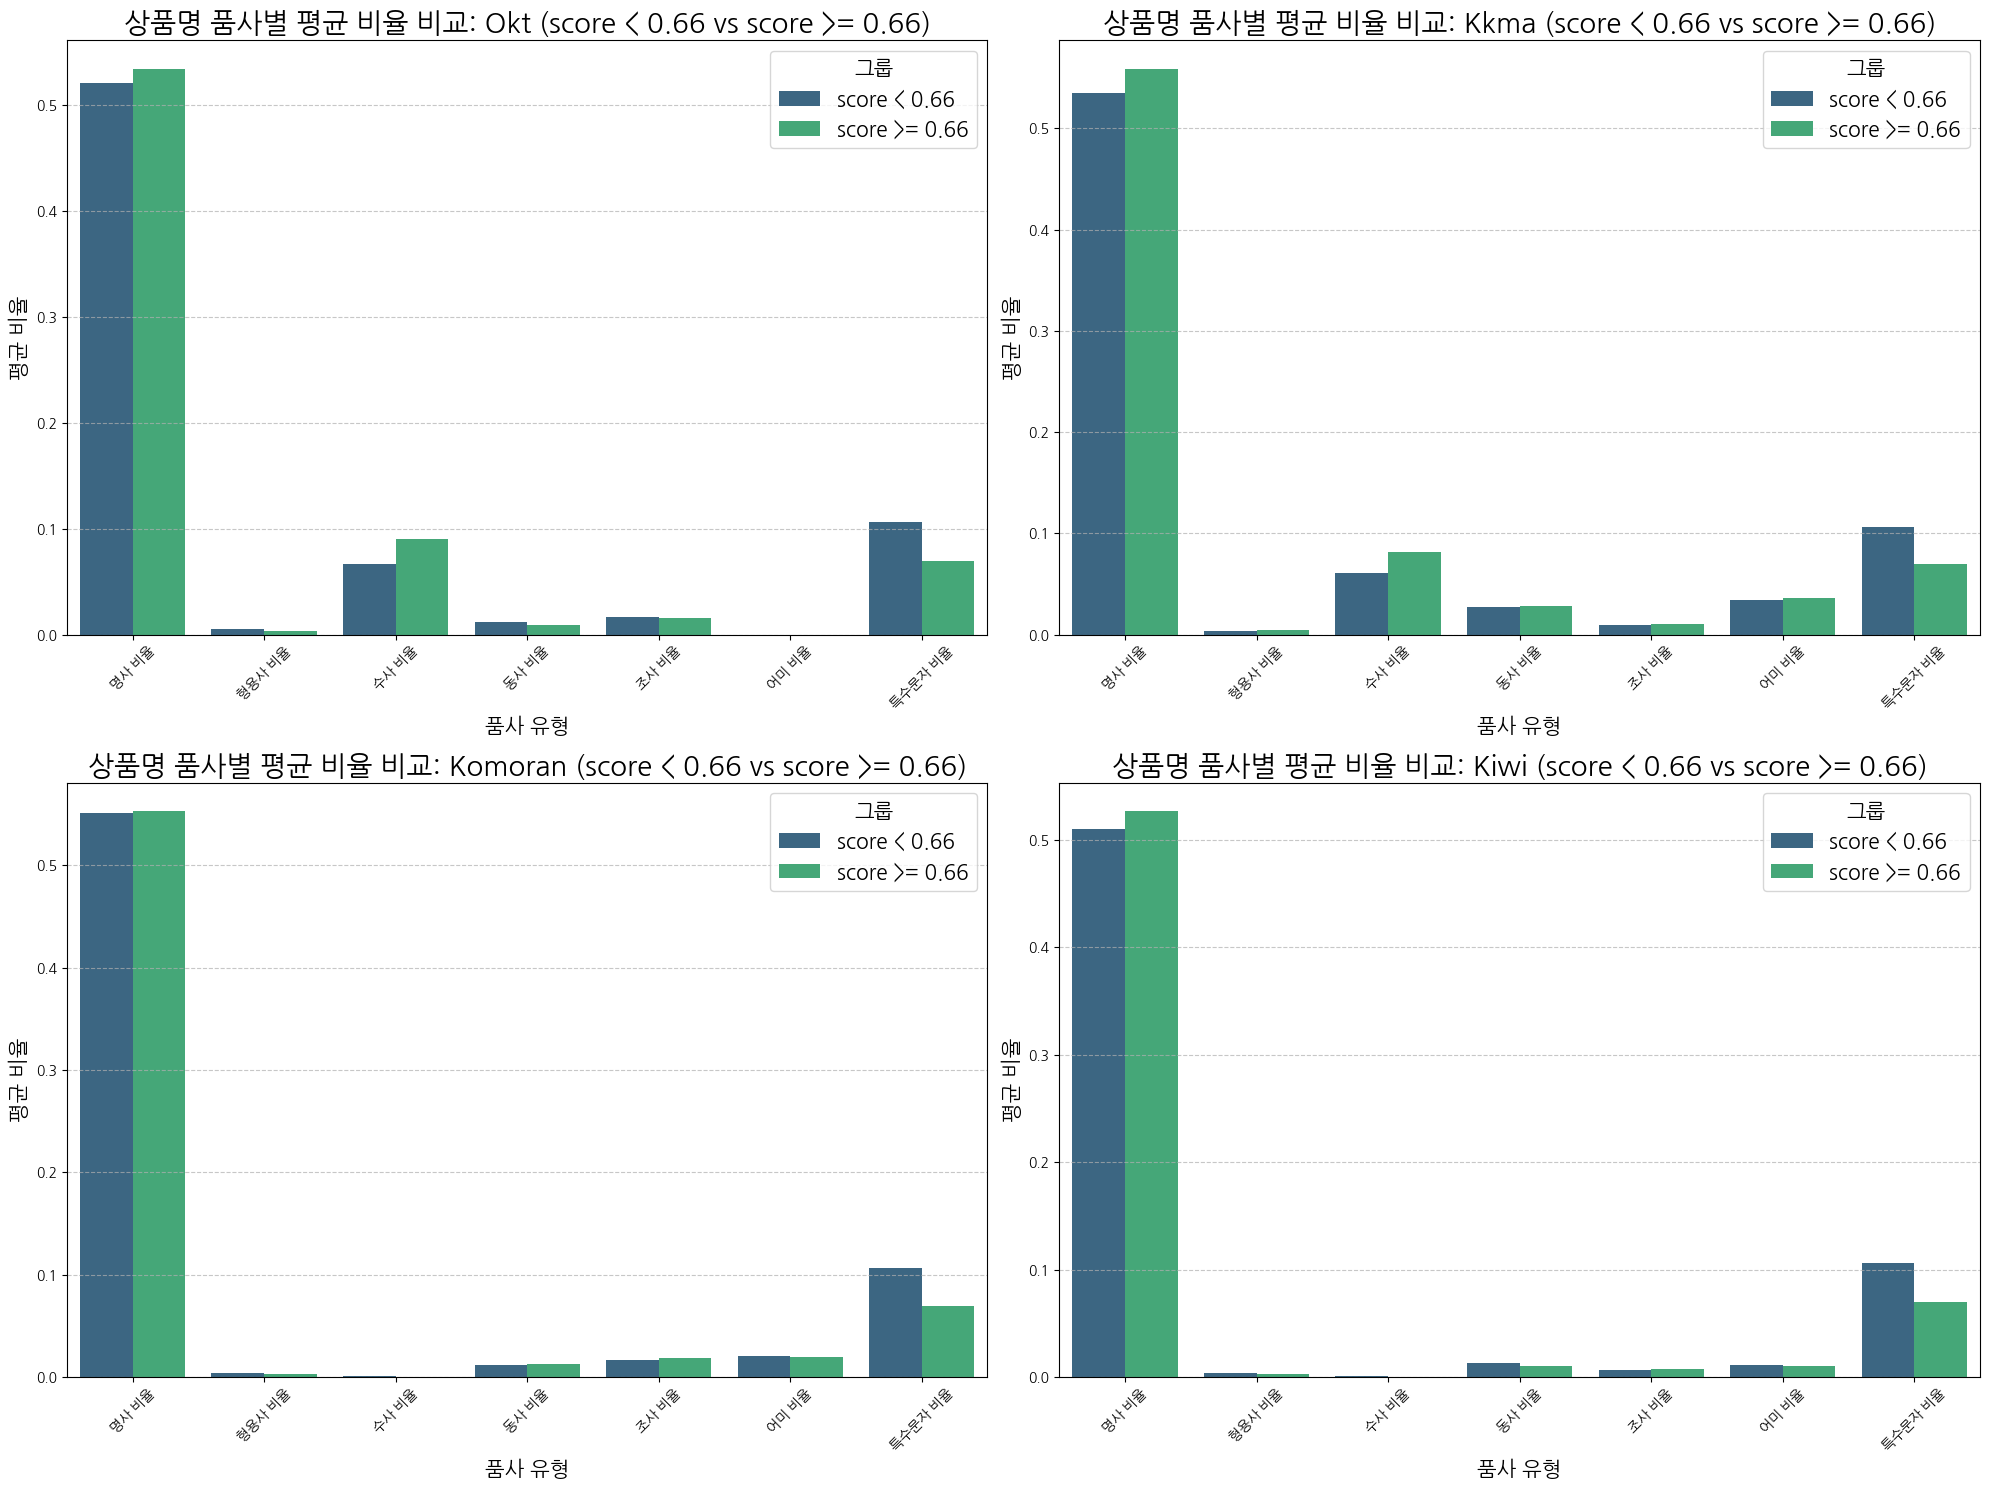

In [27]:
# '상품명' 데이터를 플로팅을 위한 DataFrame으로 변환
product_name_ratios_low_stuffing_df = pd.DataFrame({
    'Okt': avg_low_okt_product_name,
    'Kkma': avg_low_kkma_product_name,
    'Komoran': avg_low_komoran_product_name,
    'Kiwi': avg_low_kiwi_product_name
}).drop('total_pos_count', errors='ignore')
product_name_ratios_high_stuffing_df = pd.DataFrame({
    'Okt': avg_high_okt_product_name,
    'Kkma': avg_high_kkma_product_name,
    'Komoran': avg_high_komoran_product_name,
    'Kiwi': avg_high_kiwi_product_name
}).drop('total_pos_count', errors='ignore')

# Dataframe for 'low_stuffing'
product_name_ratios_low_stuffing_melted = product_name_ratios_low_stuffing_df.T.reset_index().melt(id_vars='index')
product_name_ratios_low_stuffing_melted.columns = ['Analyzer', 'POS_Type', 'Average_Ratio']
product_name_ratios_low_stuffing_melted['Group'] = 'score < 0.66'

# Dataframe for 'high_stuffing'
product_name_ratios_high_stuffing_melted = product_name_ratios_high_stuffing_df.T.reset_index().melt(id_vars='index')
product_name_ratios_high_stuffing_melted.columns = ['Analyzer', 'POS_Type', 'Average_Ratio']
product_name_ratios_high_stuffing_melted['Group'] = 'score >= 0.66'

# 두 그룹 병합
product_name_comparison_stuffing_df = pd.concat([product_name_ratios_low_stuffing_melted, product_name_ratios_high_stuffing_melted])

# 한글 품사명으로 변경 (pos_type_mapping 재활용)
product_name_comparison_stuffing_df['POS_Type'] = product_name_comparison_stuffing_df['POS_Type'].replace(pos_type_mapping);

# 요청된 순서대로 정렬 (ordered_pos_types 재활용)
product_name_comparison_stuffing_df['POS_Type'] = pd.Categorical(product_name_comparison_stuffing_df['POS_Type'], categories=ordered_pos_types, ordered=True)
product_name_comparison_stuffing_df = product_name_comparison_stuffing_df.sort_values('POS_Type')

# 각 형태소 분석기별로 그래프 생성 (Subplots 사용)
# analyzers는 이전 셀에서 정의되었으므로 재정의하지 않습니다.

fig, axes = plt.subplots(2, 2, figsize=(20, 15))
axes = axes.flatten() # 2x2 grid to 1D array for easy iteration

for i, analyzer in enumerate(analyzers):
    sns.barplot(x='POS_Type', y='Average_Ratio', hue='Group', data=product_name_comparison_stuffing_df[product_name_comparison_stuffing_df['Analyzer'] == analyzer], palette='viridis', ax=axes[i])
    axes[i].set_title(f'상품명 품사별 평균 비율 비교: {analyzer} (score < 0.66 vs score >= 0.66)', fontsize=20)
    axes[i].set_xlabel('품사 유형', fontsize=15)
    axes[i].set_ylabel('평균 비율', fontsize=15)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='그룹', title_fontsize=15, fontsize=15)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('키워드_스터핑_상품명.png')

plt.show()

#### '본문' 품사별 평균 비율 비교 ('low_stuffing' vs 'high_stuffing') 시각화

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


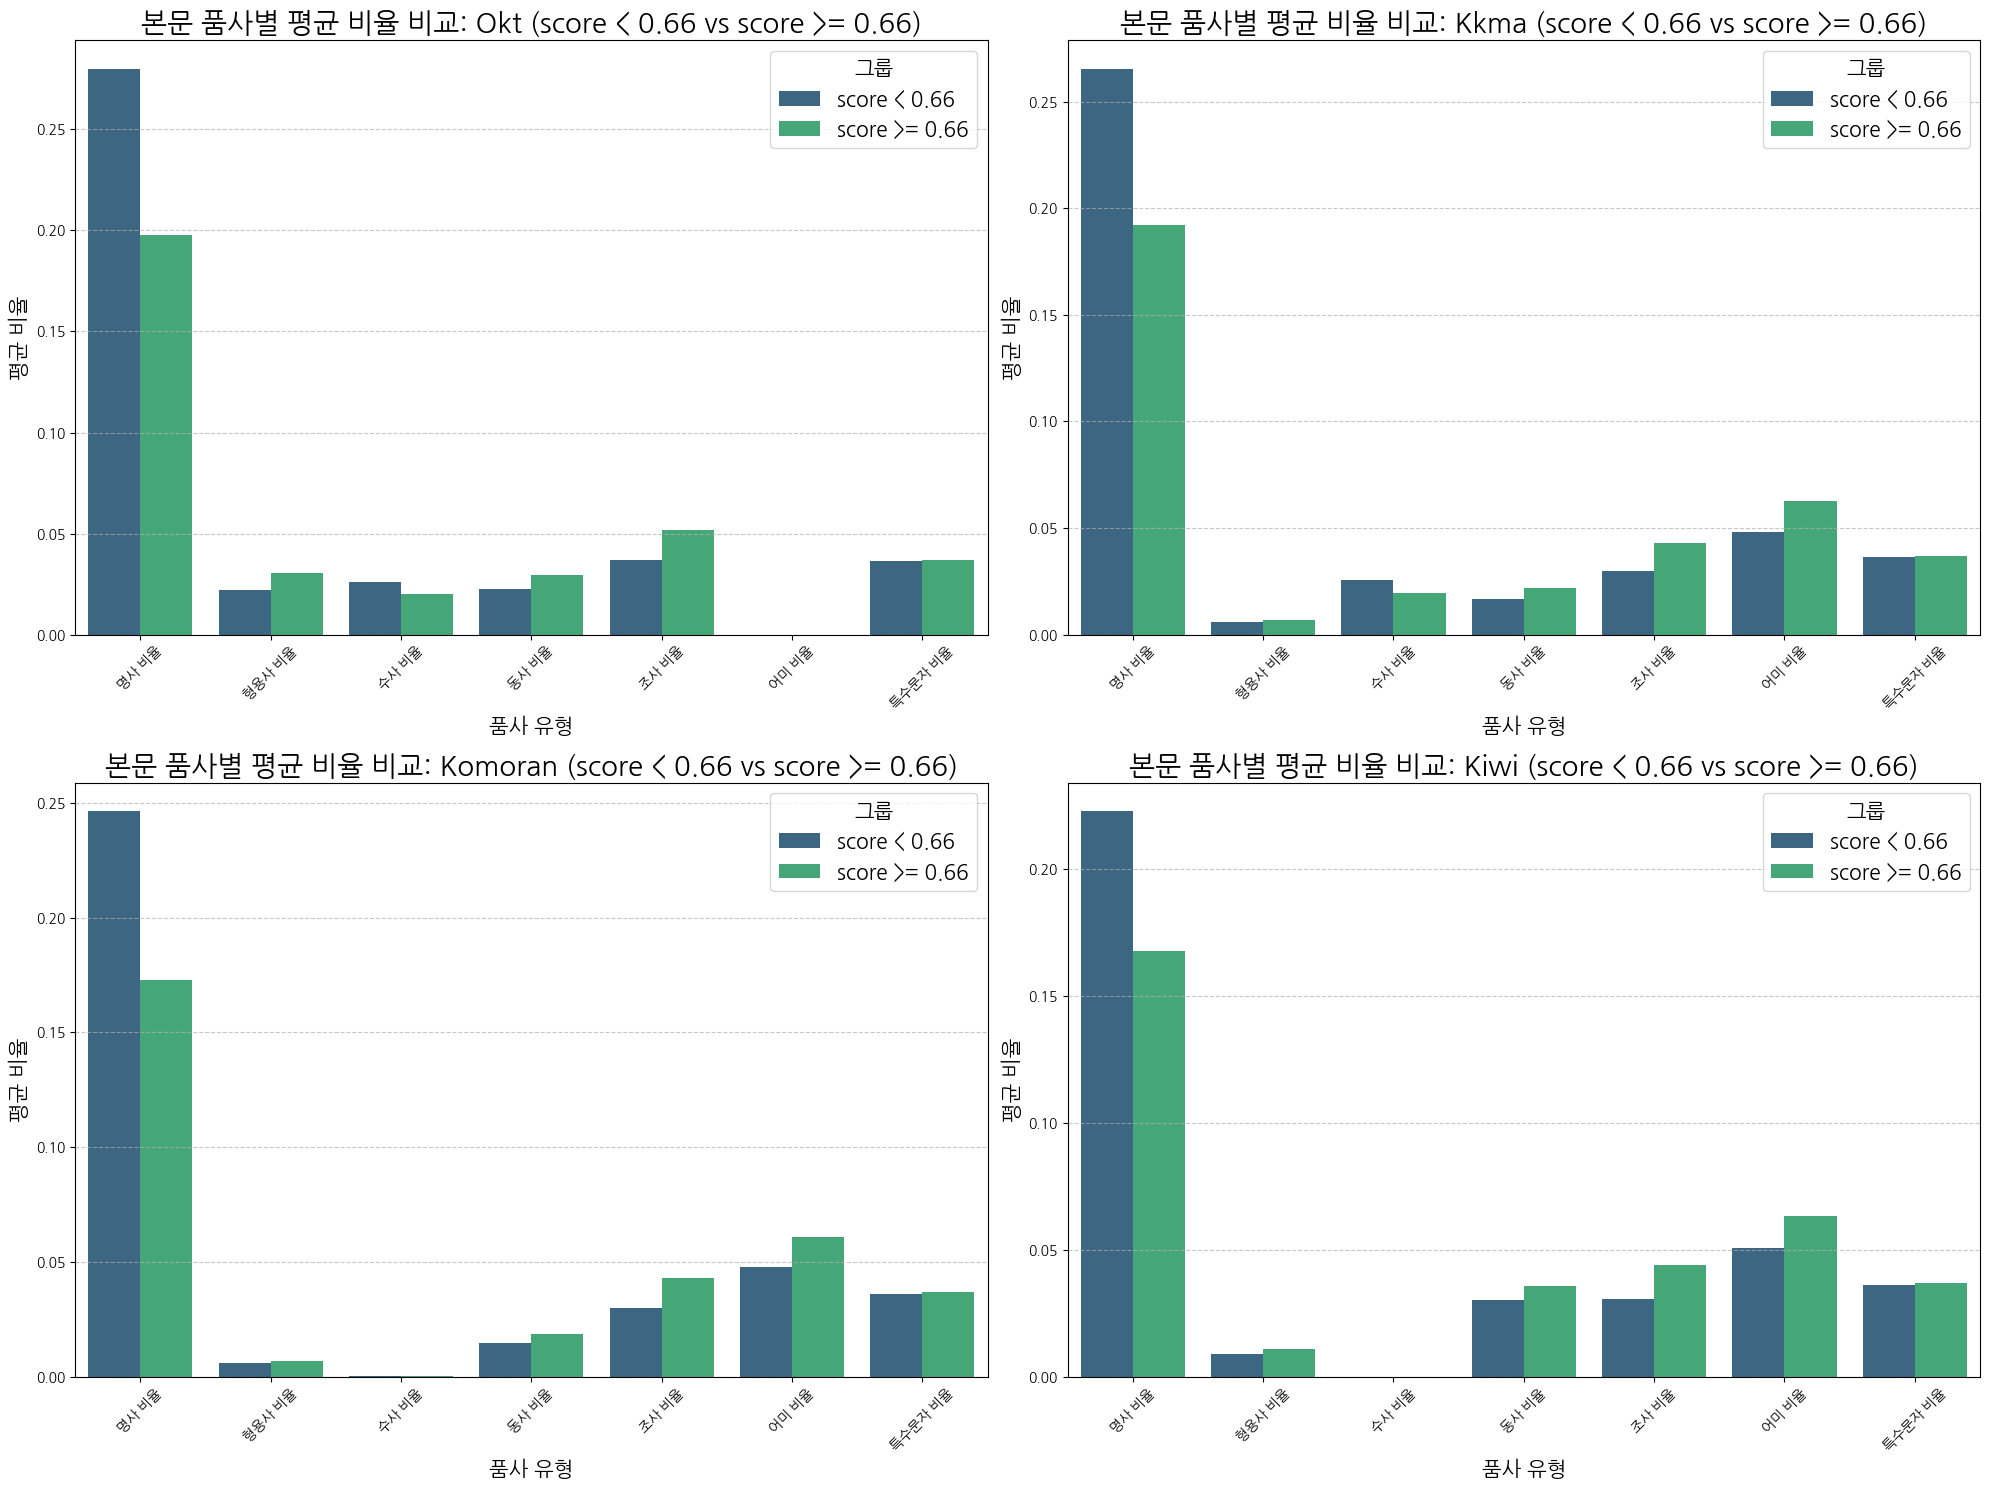

In [28]:
# '본문' 데이터를 플로팅을 위한 DataFrame으로 변환
text_contents_ratios_low_stuffing_df = pd.DataFrame({
    'Okt': avg_low_okt_text_contents,
    'Kkma': avg_low_kkma_text_contents,
    'Komoran': avg_low_komoran_text_contents,
    'Kiwi': avg_low_kiwi_text_contents
}).drop('total_pos_count', errors='ignore')
text_contents_ratios_high_stuffing_df = pd.DataFrame({
    'Okt': avg_high_okt_text_contents,
    'Kkma': avg_high_kkma_text_contents,
    'Komoran': avg_high_komoran_text_contents,
    'Kiwi': avg_high_kiwi_text_contents
}).drop('total_pos_count', errors='ignore')

# Dataframe for 'low_stuffing'
text_contents_ratios_low_stuffing_melted = text_contents_ratios_low_stuffing_df.T.reset_index().melt(id_vars='index')
text_contents_ratios_low_stuffing_melted.columns = ['Analyzer', 'POS_Type', 'Average_Ratio']
text_contents_ratios_low_stuffing_melted['Group'] = 'score < 0.66'

# Dataframe for 'high_stuffing'
text_contents_ratios_high_stuffing_melted = text_contents_ratios_high_stuffing_df.T.reset_index().melt(id_vars='index')
text_contents_ratios_high_stuffing_melted.columns = ['Analyzer', 'POS_Type', 'Average_Ratio']
text_contents_ratios_high_stuffing_melted['Group'] = 'score >= 0.66'

# 두 그룹 병합
text_contents_comparison_stuffing_df = pd.concat([text_contents_ratios_low_stuffing_melted, text_contents_ratios_high_stuffing_melted])

# 한글 품사명으로 변경 (pos_type_mapping 재활용)
text_contents_comparison_stuffing_df['POS_Type'] = text_contents_comparison_stuffing_df['POS_Type'].replace(pos_type_mapping);

# 요청된 순서대로 정렬 (ordered_pos_types 재활용)
text_contents_comparison_stuffing_df['POS_Type'] = pd.Categorical(text_contents_comparison_stuffing_df['POS_Type'], categories=ordered_pos_types, ordered=True)
text_contents_comparison_stuffing_df = text_contents_comparison_stuffing_df.sort_values('POS_Type')

# 각 형태소 분석기별로 그래프 생성 (Subplots 사용)
# analyzers는 이전 셀에서 정의되었으므로 재정의하지 않습니다.

fig, axes = plt.subplots(2, 2, figsize=(20, 15))
axes = axes.flatten() # 2x2 grid to 1D array for easy iteration

for i, analyzer in enumerate(analyzers):
    sns.barplot(x='POS_Type', y='Average_Ratio', hue='Group', data=text_contents_comparison_stuffing_df[text_contents_comparison_stuffing_df['Analyzer'] == analyzer], palette='viridis', ax=axes[i])
    axes[i].set_title(f'본문 품사별 평균 비율 비교: {analyzer} (score < 0.66 vs score >= 0.66)', fontsize=20)
    axes[i].set_xlabel('품사 유형', fontsize=15)
    axes[i].set_ylabel('평균 비율', fontsize=15)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='그룹', title_fontsize=15, fontsize=15)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.savefig('키워드_스터핑_본문.png')

plt.show()